In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
import pandas as pd
import numpy as np

import torch
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

FILE_PATH = '/content/drive/MyDrive/Dataset/student_dataset_10000_rows.csv'
df = pd.read_csv(FILE_PATH)

X = df.drop("placement_status", axis=1)
y = df["placement_status"]

encoder = LabelEncoder()
y = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

print(f'Training size: {X_train.shape}')
print(f'Validation size: {X_val.shape}')
print(f'Testing size: {X_test.shape}')

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

Training size: torch.Size([6000, 7])
Validation size: torch.Size([2000, 7])
Testing size: torch.Size([2000, 7])


In [ ]:
import torch.nn as nn

class StudentClassifier(nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(num_features, 32),
            nn.LeakyReLU(),

            nn.Linear(32, 16),
            nn.LeakyReLU(),

            nn.Linear(16, 2)
        )

    def forward(self, x):
        return self.network(x)

num_features = X_train.shape[1]
print(f'Feature count: {num_features}')
print(f'Features: {list(X)}')
print(encoder.classes_)
model = StudentClassifier(num_features)

Feature count: 7
Features: ['study_hours', 'attendance', 'sleep_hours', 'internet_usage', 'assignments_completed', 'previous_score', 'exam_score']
['Not Placed' 'Placed']


Epoch [1/90]: Training Loss: 0.7242, Validation Loss: 0.6392
Epoch [2/90]: Training Loss: 0.6411, Validation Loss: 0.5648
Epoch [3/90]: Training Loss: 0.5666, Validation Loss: 0.4964
Epoch [4/90]: Training Loss: 0.4978, Validation Loss: 0.4368
Epoch [5/90]: Training Loss: 0.4374, Validation Loss: 0.3893
Epoch [6/90]: Training Loss: 0.3888, Validation Loss: 0.3546
Epoch [7/90]: Training Loss: 0.3528, Validation Loss: 0.3297
Epoch [8/90]: Training Loss: 0.3266, Validation Loss: 0.3102
Epoch [9/90]: Training Loss: 0.3057, Validation Loss: 0.2925
Epoch [10/90]: Training Loss: 0.2869, Validation Loss: 0.2750
Epoch [11/90]: Training Loss: 0.2687, Validation Loss: 0.2578
Epoch [12/90]: Training Loss: 0.2512, Validation Loss: 0.2419
Epoch [13/90]: Training Loss: 0.2353, Validation Loss: 0.2280
Epoch [14/90]: Training Loss: 0.2215, Validation Loss: 0.2167
Epoch [15/90]: Training Loss: 0.2100, Validation Loss: 0.2076
Epoch [16/90]: Training Loss: 0.2009, Validation Loss: 0.2003
Epoch [17/90]: Tr

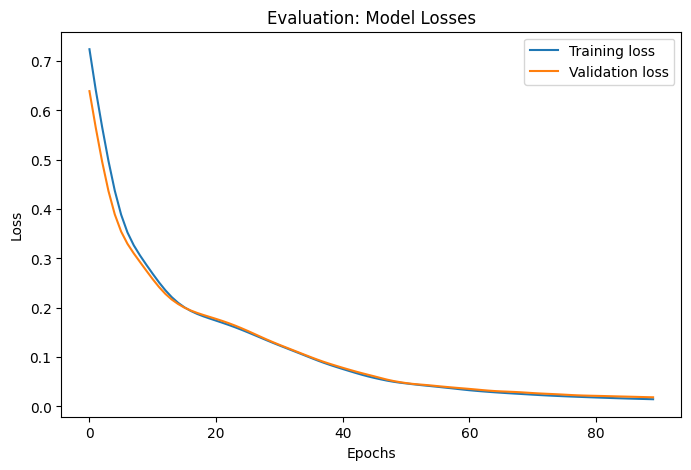

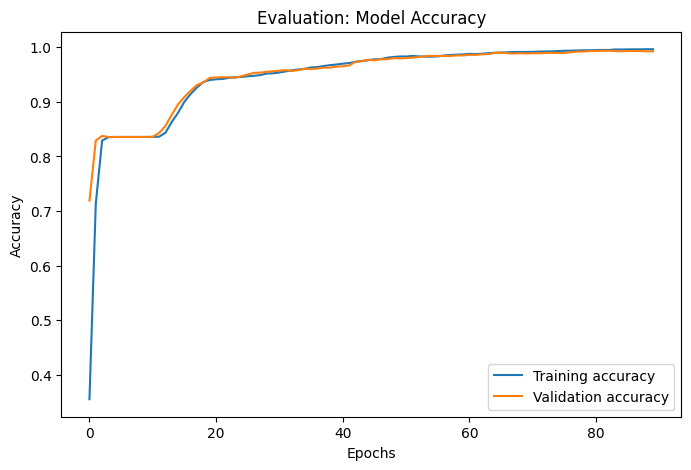

In [ ]:
import torch.optim as optim
import matplotlib.pyplot as plt

epochs = 90
rate = 1e-2

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=rate)

losses = [[], []]
acc = [[], []]
for epoch in range(epochs):
    model.train()
    outputs = model(X_train)
    train_loss = criterion(outputs, y_train)
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()
    losses[0].append(train_loss.item())

    _, train_out = torch.max(outputs, 1)
    train_acc = (train_out == y_train).float().mean()
    acc[0].append(train_acc)

    model.eval()
    val_outputs = model(X_val)
    _, val_out = torch.max(val_outputs, 1)
    val_acc = (val_out == y_val).float().mean()
    acc[1].append(val_acc)

    val_loss = criterion(val_outputs, y_val)
    losses[1].append(val_loss.item())

    print(f"Epoch [{epoch+1}/{epochs}]: Training Loss: {train_loss.item():.4f}, ", end='')
    print(f"Validation Loss: {val_loss.item():.4f}")

plt.figure(figsize=(8,5))
plt.plot(losses[0], label='Training loss')
plt.plot(losses[1], label='Validation loss')
plt.legend()
plt.title('Evaluation: Model Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

print()
plt.figure(figsize=(8,5))
plt.plot(acc[0], label='Training accuracy')
plt.plot(acc[1], label='Validation accuracy')
plt.legend()
plt.title('Evaluation: Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

model.eval()

with torch.no_grad():
    outputs = model(X_test)
    _, y_pred = torch.max(outputs, 1)
    accuracy = (y_pred == y_test).float().mean()
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

Confusion Matrix:
[[ 317   12]
 [   5 1666]]

Test Accuracy: 99.15%


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

model = models.resnet18(weights='DEFAULT')

for param in model.parameters():
    param.requires_grad = False

# 3. Replace the final fully connected layer (fc)
# ResNet18's fc layer input features are 512
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

# 4. Optimizer: only parameters of the final layer are being optimized
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

print("ResNet18 transfer learning setup complete!")
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 148MB/s]

ResNet18 transfer learning setup complete!
Linear(in_features=512, out_features=2, bias=True)


### Adapting Tabular Data for ResNet
ResNet18 expects a specific input shape. We will use a linear layer to project our 7 features into the 512-dimensional space that the ResNet head expects.

In [ ]:
import torch.optim as optim
import pandas as pd

projection_layer = nn.Linear(7, 512)
optimizer = optim.Adam(list(projection_layer.parameters()) + list(model.fc.parameters()), lr=0.001)
criterion = nn.CrossEntropyLoss()

resnet_losses = {'train': [], 'val': []}
epochs = 90

for epoch in range(epochs):
    model.train()
    projection_layer.train()

    feat_projected = projection_layer(X_train)
    outputs = model.fc(feat_projected)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    resnet_losses['train'].append(loss.item())

    model.eval()
    projection_layer.eval()
    with torch.no_grad():
        val_projected = projection_layer(X_val)
        val_outputs = model.fc(val_projected)
        v_loss = criterion(val_outputs, y_val)
        resnet_losses['val'].append(v_loss.item())

all_epochs_df = pd.DataFrame({
    'Epoch': range(1, epochs + 1),
    'Train Loss': resnet_losses['train'],
    'Val Loss': resnet_losses['val']
})

print("Full Training Results for ResNet18 Transfer Learning (90 Epochs):")
display(all_epochs_df.style.format({'Train Loss': '{:.4f}', 'Val Loss': '{:.4f}'}))

Full Training Results for ResNet18 Transfer Learning (90 Epochs):


,Epoch,Train Loss,Val Loss
0,1,0.5110,0.4331
1,2,0.4323,0.3691
2,3,0.3676,0.3179
3,4,0.3159,0.2778
4,5,0.2753,0.2468
5,6,0.2438,0.2227
6,7,0.2194,0.2038
7,8,0.2002,0.1888
8,9,0.1849,0.1765
9,10,0.1723,0.1661


### Final Confusion Matrix Comparison
We will now generate the final predictions for the ResNet18 model and compare its confusion matrix with the Custom MLP model to see the distribution of True Positives, True Negatives, False Positives, and False Negatives.

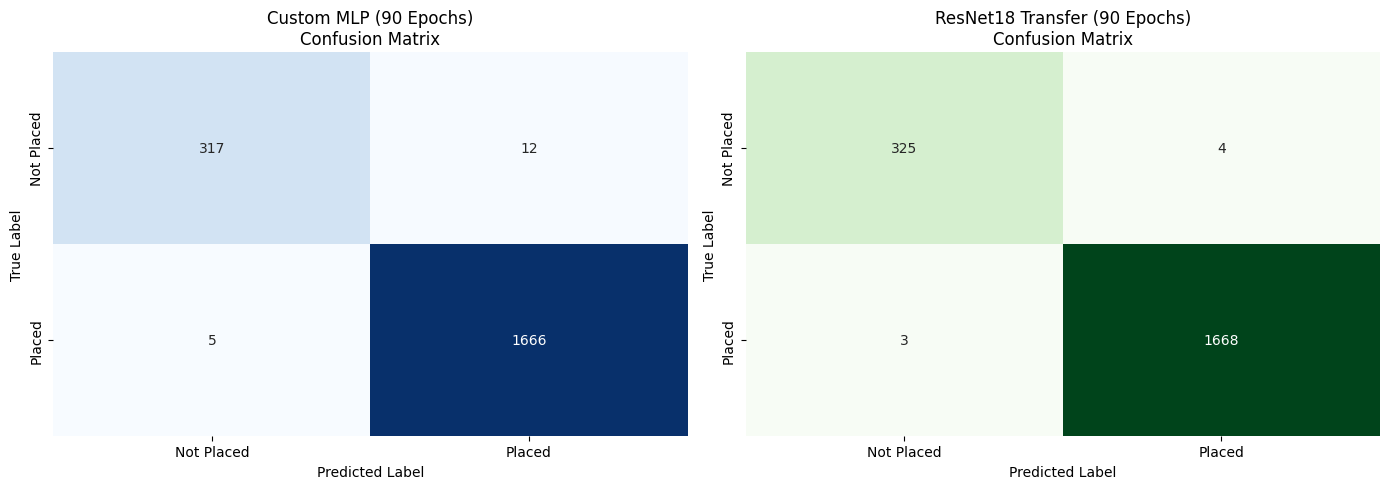

Custom MLP Final Accuracy: 99.15%
ResNet18 Transfer Final Accuracy: 99.65%


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

model.eval()
projection_layer.eval()
with torch.no_grad():
    test_projected = projection_layer(X_test)
    test_outputs = model.fc(test_projected)
    _, y_pred_resnet_90 = torch.max(test_outputs, 1)

cm_custom = confusion_matrix(y_test, y_pred)
cm_resnet_90 = confusion_matrix(y_test, y_pred_resnet_90)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_custom, annot=True, fmt='d', ax=ax[0], cmap='Blues', cbar=False)
ax[0].set_title('Custom MLP (90 Epochs)\nConfusion Matrix')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')
ax[0].set_xticklabels(['Not Placed', 'Placed'])
ax[0].set_yticklabels(['Not Placed', 'Placed'])

sns.heatmap(cm_resnet_90, annot=True, fmt='d', ax=ax[1], cmap='Greens', cbar=False)
ax[1].set_title('ResNet18 Transfer (90 Epochs)\nConfusion Matrix')
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('True Label')
ax[1].set_xticklabels(['Not Placed', 'Placed'])
ax[1].set_yticklabels(['Not Placed', 'Placed'])

plt.tight_layout()
plt.show()

resnet_acc_90 = (y_pred_resnet_90 == y_test).float().mean()
print(f"Custom MLP Final Accuracy: {accuracy*100:.2f}%")
print(f"ResNet18 Transfer Final Accuracy: {resnet_acc_90*100:.2f}%")